# Deepfake Audio Detection – Using SSL
**Architecture:** Mel-spectrogram → Contrastive Pre-training (NT-Xent) → BiGRU Classifier

> All modules (`config`, `dataset`, `models`, `losses`, `embeddings`, `train`, `visualize`, `inference`) must be in the **same directory** as this notebook.

## 0. Imports & Setup

In [1]:
import os
import sys
import warnings
import numpy as np
import torch
from torch.utils.data import DataLoader, SubsetRandomSampler
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')

# ── Local modules (keep all .py files in the same folder) ──
import config
from dataset import (
    DeepfakeAudioDataset,
    extract_log_mel_spectrograms,
    collate_variable_length
)
from embeddings import generate_rnn_embeddings
from models import BiGRUClassifier, count_parameters
from train import pretrain_contrastive, train_classifier, evaluate, print_results
from visualize import (
    plot_training_curves,
    plot_tsne,
    plot_confusion_matrix,
    plot_roc_eer
)

print(f'Device : {config.DEVICE}')
print(f'PyTorch: {torch.__version__}')

Device : mps
PyTorch: 2.9.1


## 1. Configuration
Edit these variables to override `config.py` defaults.

In [2]:
# ── Override config values here if needed ──────────────────
DATA_DIR        = 'data'   # root with real/ and fake/ subfolders
EPOCHS          = 20
PRETRAIN_EPOCHS = 10
BATCH_SIZE      = 16
LR              = 5e-4
SKIP_PRETRAIN   = False    # set True to skip Phase 1

# Apply to config module
config.DATA_DIR      = DATA_DIR
config.REAL_DIR      = os.path.join(DATA_DIR, 'real')
config.FAKE_DIR      = os.path.join(DATA_DIR, 'fake')
config.EPOCHS        = EPOCHS
config.BATCH_SIZE    = BATCH_SIZE
config.LEARNING_RATE = LR

print(f'Data   : {config.DATA_DIR}')
print(f'Epochs : {config.EPOCHS}')
print(f'Batch  : {config.BATCH_SIZE}')
print(f'LR     : {config.LEARNING_RATE}')

Data   : data
Epochs : 20
Batch  : 16
LR     : 0.0005


## 2. Load Dataset

In [3]:
# Validate directories
for d in [config.REAL_DIR, config.FAKE_DIR]:
    if not os.path.isdir(d):
        raise FileNotFoundError(f'Missing directory: {d}')

dataset = DeepfakeAudioDataset(config.REAL_DIR, config.FAKE_DIR)
labels  = [s[1] for s in dataset.samples]
n_real  = labels.count(0)
n_fake  = labels.count(1)

print(f'Total samples : {len(dataset)}')
print(f'Real          : {n_real}')
print(f'Fake          : {n_fake}')

if len(dataset) == 0:
    raise RuntimeError('No audio files found. Check your data directory.')

Total samples : 39862
Real          : 19963
Fake          : 19899


## 3. Phase 1 – Contrastive Pre-training (NT-Xent)

In [4]:
from models import GRUEmbedder

pretrained_encoder = None

if not SKIP_PRETRAIN:
    if os.path.exists(config.PRETRAIN_PATH):
        # ── Checkpoint exists: load from disk (skip 120-min training) ──
        pretrained_encoder = GRUEmbedder().to(config.DEVICE)
        pretrained_encoder.load_state_dict(
            torch.load(config.PRETRAIN_PATH, map_location=config.DEVICE)
        )
        pretrained_encoder.eval()
        print(f'✓ Loaded pretrained encoder from {config.PRETRAIN_PATH}')
    else:
        # ── No checkpoint: run full contrastive pre-training ──
        contra_model       = pretrain_contrastive(dataset, epochs=PRETRAIN_EPOCHS)
        pretrained_encoder = contra_model.encoder
else:
    print('Phase 1 skipped — training classifier from scratch.')


✓ Loaded pretrained encoder from artifacts/pretrained_encoder.pth


## 4. Phase 2 – Supervised BiGRU Classification

In [5]:
from models import FineTunedModel, GRUEmbedder

if os.path.exists(config.BEST_MODEL_PATH):
    # ── Checkpoint exists: load trained model, skip retraining ──
    _encoder = GRUEmbedder().to(config.DEVICE)
    model = FineTunedModel(_encoder).to(config.DEVICE)
    model.load_state_dict(
        torch.load(config.BEST_MODEL_PATH, map_location=config.DEVICE)
    )
    model.eval()
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    print(f'✓ Loaded trained model from {config.BEST_MODEL_PATH}')
else:
    model, history = train_classifier(
        dataset,
        pretrained_encoder=pretrained_encoder,
        epochs=config.EPOCHS
    )

✓ Loaded trained model from artifacts/best_audio_model.pth


In [10]:
import importlib, paper_figures
importlib.reload(paper_figures)

paper_figures.generate_all(
    model=model,                        # your trained FineTunedModel
    history=history,                    # from train_classifier()
    dataset=dataset,                    # DeepfakeAudioDataset
    results=results,                    # from evaluate()
    y_true=y_true,
    y_pred=y_pred,
    y_prob=y_prob,
    pretrained_encoder=pretrained_encoder,
)


  Generating Paper Figures

[FIG 1] Dataset distribution …
  [✓] Saved → artifacts/plots/fig1_dataset_distribution.png

[FIG 2] Sample waveforms …
  [✓] Saved → artifacts/plots/fig2_sample_waveforms.png

[FIG 3] Mel spectrograms …
  [✓] Saved → artifacts/plots/fig3_mel_spectrograms.png

[FIG 11] Mean Mel-band energy …
  [✓] Saved → artifacts/plots/fig11_mean_mel_energy.png

[FIG 4] Training curves …
  [SKIP] No training history available.

[FIG 5] Confusion matrix …
  [✓] Saved → artifacts/plots/fig5_confusion_matrix.png

[FIG 6] ROC + EER curves …
  [✓] Saved → artifacts/plots/fig6_roc_eer.png

[FIG 7] Precision-Recall curve …
  [✓] Saved → artifacts/plots/fig7_precision_recall.png

[FIG 8] Score distribution …
  [✓] Saved → artifacts/plots/fig8_score_distribution.png

[FIG 9] t-SNE of embeddings …
  [t-SNE] Fitting on 500 samples …
  [SKIP] TSNE.__init__() got an unexpected keyword argument 'n_iter'

[FIG 10] PCA of embeddings …
  [✓] Saved → artifacts/plots/fig10_pca_embeddings.png


{'fig1': 'artifacts/plots/fig1_dataset_distribution.png',
 'fig2': 'artifacts/plots/fig2_sample_waveforms.png',
 'fig3': 'artifacts/plots/fig3_mel_spectrograms.png',
 'fig11': 'artifacts/plots/fig11_mean_mel_energy.png',
 'fig4': None,
 'fig5': 'artifacts/plots/fig5_confusion_matrix.png',
 'fig6': 'artifacts/plots/fig6_roc_eer.png',
 'fig7': 'artifacts/plots/fig7_precision_recall.png',
 'fig8': 'artifacts/plots/fig8_score_distribution.png',
 'fig10': 'artifacts/plots/fig10_pca_embeddings.png',
 'fig12': 'artifacts/plots/fig12_metrics_table.png'}

In [11]:
import json
from models import FineTunedModel, GRUEmbedder

HISTORY_PATH = "artifacts/training_history.json"

if os.path.exists(config.BEST_MODEL_PATH):
    # Load trained model from checkpoint
    _encoder = GRUEmbedder().to(config.DEVICE)
    model = FineTunedModel(_encoder).to(config.DEVICE)
    model.load_state_dict(
        torch.load(config.BEST_MODEL_PATH, map_location=config.DEVICE)
    )
    model.eval()
    print(f'✓ Loaded trained model from {config.BEST_MODEL_PATH}')

    # Load training history if it exists
    if os.path.exists(HISTORY_PATH):
        with open(HISTORY_PATH) as f:
            history = json.load(f)
        print(f'✓ Loaded history from {HISTORY_PATH}')
    else:
        history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
        print('⚠ No history file found — plots will be empty. Retrain once to save it.')
else:
    model, history = train_classifier(
        dataset,
        pretrained_encoder=pretrained_encoder,
        epochs=config.EPOCHS
    )


✓ Loaded trained model from artifacts/best_audio_model.pth
⚠ No history file found — plots will be empty. Retrain once to save it.


## 5. Evaluation

In [6]:
from models import FineTunedModel, GRUEmbedder

_, val_idx = train_test_split(
    list(range(len(dataset))),
    test_size=config.VAL_SPLIT,
    stratify=labels,
    random_state=config.RANDOM_STATE
)

val_loader = DataLoader(
    dataset,
    batch_size=config.BATCH_SIZE,
    sampler=SubsetRandomSampler(val_idx),
    collate_fn=collate_variable_length
)

# Load best checkpoint (saved as FineTunedModel)
_encoder   = GRUEmbedder().to(config.DEVICE)
best_model = FineTunedModel(_encoder).to(config.DEVICE)
best_model.load_state_dict(
    torch.load(config.BEST_MODEL_PATH, map_location=config.DEVICE)
)
best_model.eval()
print(f'✓ Loaded best model from {config.BEST_MODEL_PATH}')

results, y_true, y_pred, y_prob = evaluate(best_model, val_loader)
print_results(results)


✓ Loaded best model from artifacts/best_audio_model.pth

Evaluation Results
  Accuracy      : 0.9957 (99.57%)
  Precision     : 0.9982 (99.82%)
  Recall        : 0.9932 (99.32%)
  F1-Score      : 0.9957 (99.57%)
  AUC-ROC       : 0.9994
  EER           : 0.0050 (0.50%)
  EER Threshold : 0.0478


## 6. Generate Embeddings

In [7]:
print('Generating log-Mel spectrograms + RNN embeddings …')
specs, fnames   = extract_log_mel_spectrograms(config.DATA_DIR)
emb_matrix, _   = generate_rnn_embeddings(specs, fnames)
print(f'Embedding matrix shape: {emb_matrix.shape}')

Generating log-Mel spectrograms + RNN embeddings …
[ExtractLogMelSpectrograms] Extracted: 39862/39862
[GenerateRNNEmbeddings] Saved 39862 embeddings
  → artifacts/embeddings.pt
  → artifacts/embeddings.npy
  → artifacts/embeddings.csv
Embedding matrix shape: (39862, 128)


## 7. Visualizations

[Plot] Saved → artifacts/plots/training_curves.png


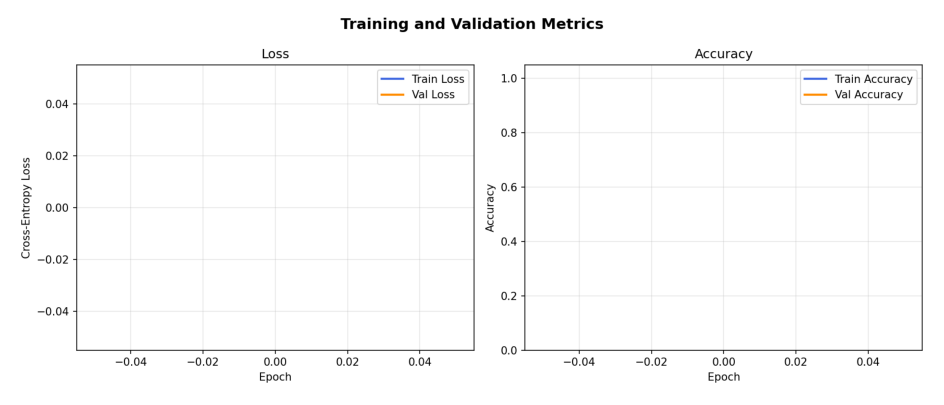

In [8]:
import matplotlib
matplotlib.use('Agg')   # change to 'inline' if plots don't show
import matplotlib.pyplot as plt
%matplotlib inline

# Training curves
plot_training_curves(history)
img = plt.imread('artifacts/plots/training_curves.png')
plt.figure(figsize=(12, 5)); plt.imshow(img); plt.axis('off'); plt.show()

In [9]:
# t-SNE
y_true_arr = np.array(y_true)
val_embs   = (
    emb_matrix[val_idx[:len(y_true_arr)]]
    if len(emb_matrix) >= len(val_idx)
    else emb_matrix[:len(y_true_arr)]
)
if len(val_embs) == len(y_true_arr):
    plot_tsne(val_embs, y_true_arr)
    img = plt.imread('artifacts/plots/tsne.png')
    plt.figure(figsize=(8, 7)); plt.imshow(img); plt.axis('off'); plt.show()

[t-SNE] Running dimensionality reduction …


TypeError: TSNE.__init__() got an unexpected keyword argument 'n_iter'

In [ ]:
# Confusion matrix
plot_confusion_matrix(np.array(y_true), np.array(y_pred))
img = plt.imread('artifacts/plots/confusion_matrix.png')
plt.figure(figsize=(5, 5)); plt.imshow(img); plt.axis('off'); plt.show()

In [ ]:
# ROC + EER
plot_roc_eer(
    np.array(y_true), np.array(y_prob),
    results['eer'], results['eer_threshold']
)
img = plt.imread('artifacts/plots/roc_eer.png')
plt.figure(figsize=(12, 5)); plt.imshow(img); plt.axis('off'); plt.show()

## 8. Inference on New Files

In [ ]:
from inference import load_classifier, predict_batch

# ── Edit this list with your own audio files ───────────────
TEST_FILES = [
    # 'path/to/audio1.wav',
    # 'path/to/audio2.mp3',
]

if TEST_FILES:
    inf_model = load_classifier(config.BEST_MODEL_PATH)
    results_inf = predict_batch(TEST_FILES, inf_model)
else:
    print('Add file paths to TEST_FILES to run inference.')

## 9. Summary

In [ ]:
print('=' * 60)
print('  Pipeline complete.')
print(f'  Best model   → {config.BEST_MODEL_PATH}')
print(f'  Plots        → artifacts/plots/')
print(f'  Embeddings   → {config.EMBEDDINGS_NPY}')
print('=' * 60)